# Stage 5 — Headline Results: SDR/PESQ + Robustness Story

Stages 1-4 proved every mechanism in isolation on toy data. This stage trains on real
speech and produces the paper-style headline plot: reconstruction quality (SDR, and
PESQ if available) vs SNR, across channel types, for one model.

**This notebook targets the Edinburgh DataShare 28-speaker set** (Valentini 2016,
`clean_trainset_wav` — DeepSC-S transmits/reconstructs speech, not denoising, so the
*clean* set is correct, not the noisy one). The download is several GB and is **not**
fetched automatically — see the data-check cell below. Every other cell runs
end-to-end on the toy dataset if the real data isn't present, so the pipeline itself is
fully verified even without the download.

In [49]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from deepscs.audio import SR, W, F, L, deframe, sdr
from deepscs.data import ToyDataset, SpeechDataset
from deepscs.model import DeepSC_S
from deepscs.channel import ChannelLayer

try:
    from pesq import pesq as pesq_fn
    HAVE_PESQ = True
except ImportError:
    HAVE_PESQ = False

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams["figure.figsize"] = (10, 3)

# CPU, not MPS: MPS's autograd for torch.complex ops (used by the channel layer)
# doesn't support backward through non-contiguous views yet; at this data scale
# CPU is fast enough that it doesn't matter here.
device = torch.device("cpu")
print("device:", device, " | pesq available:", HAVE_PESQ)

device: cpu  | pesq available: True


In [50]:
DATA_DIR = pathlib.Path("../data/clean_trainset_wav")
TEST_DIR = pathlib.Path("../data/clean_testset_wav")

USE_REAL_DATA = DATA_DIR.exists() and any(DATA_DIR.glob("*.wav"))

if not USE_REAL_DATA:
    print(f"""No real speech data found under {DATA_DIR}.

This stage is designed to run on the Edinburgh DataShare 28-speaker set
(10283/2791): https://datashare.ed.ac.uk/handle/10283/2791

    mkdir -p ../data && cd ../data
    curl -L -o clean_trainset.zip \
      "https://datashare.ed.ac.uk/bitstream/handle/10283/2791/clean_trainset_wav.zip"
    unzip clean_trainset.zip

That's a multi-GB download, deliberately not fetched automatically by this notebook.
Falling back to the toy synthetic dataset so every cell below still runs end-to-end —
swap USE_REAL_DATA to True (and point DATA_DIR/TEST_DIR at the unzipped folders) once
the real set is downloaded; no other code in this notebook needs to change.""")
else:
    print(f"found real data at {DATA_DIR}")

No real speech data found under ../data/clean_trainset_wav.

This stage is designed to run on the Edinburgh DataShare 28-speaker set
(10283/2791): https://datashare.ed.ac.uk/handle/10283/2791

    mkdir -p ../data && cd ../data
    curl -L -o clean_trainset.zip       "https://datashare.ed.ac.uk/bitstream/handle/10283/2791/clean_trainset_wav.zip"
    unzip clean_trainset.zip

That's a multi-GB download, deliberately not fetched automatically by this notebook.
Falling back to the toy synthetic dataset so every cell below still runs end-to-end —
swap USE_REAL_DATA to True (and point DATA_DIR/TEST_DIR at the unzipped folders) once
the real set is downloaded; no other code in this notebook needs to change.


## Datasets + training subset

Default training subset ~2k clips is tractable on a single Colab GPU session (docs #CHOICE — full 10k noted as an extension, not required to reproduce the qualitative story).

In [51]:
N_TRAIN_SUBSET = 2000  # docs #CHOICE: ~2k clips for a tractable single-session train
N_TOY_TRAIN = 32        # small stand-in so this cell is fast without real data
N_EPOCHS = 40 if USE_REAL_DATA else 400
CHECKPOINT_EVERY = max(N_EPOCHS // 4, 1)

if USE_REAL_DATA:
    full_train = SpeechDataset(DATA_DIR, train=True, seed=0)
    idx = np.random.default_rng(0).choice(len(full_train), size=min(N_TRAIN_SUBSET, len(full_train)), replace=False)
    train_ds = torch.utils.data.Subset(full_train, idx.tolist())
    test_ds = SpeechDataset(TEST_DIR, train=False, seed=1) if TEST_DIR.exists() else None
else:
    train_ds = ToyDataset(n=N_TOY_TRAIN, length=W, seed=0)
    test_ds = ToyDataset(n=8, length=W, seed=99)

print(f"train clips: {len(train_ds)}, epochs: {N_EPOCHS}")

train clips: 32, epochs: 400


## Train with checkpointing

Checkpoint every few epochs to build a reconstruction-quality-over-time gallery below.

In [52]:
loader = torch.utils.data.DataLoader(train_ds, batch_size=8, shuffle=True, drop_last=True)

model = DeepSC_S(depth=8, n_blocks=4).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
channel = ChannelLayer("awgn", snr_db=10.0)

import pathlib as _pl
_ckpt_path = _pl.Path("../checkpoints/deepsc_s_awgn_final.pt")

checkpoints = {}  # epoch -> state_dict (cpu)
epoch_losses = []
if _ckpt_path.exists():
    model.load_state_dict(torch.load(_ckpt_path, map_location=device))
    checkpoints["final"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"found existing checkpoint at {_ckpt_path}, skipping training")
else:
    for epoch in range(N_EPOCHS):
        running = 0.0
        for batch in loader:
            batch = batch.to(device).view(-1, 1, F, L)
            channel.snr_db = float(np.random.uniform(0, 20))
            opt.zero_grad()
            x_hat = model(batch, channel=channel)
            loss = loss_fn(x_hat, batch)
            loss.backward()
            opt.step()
            running += loss.item()
        epoch_losses.append(running / len(loader))
        if epoch % CHECKPOINT_EVERY == 0 or epoch == N_EPOCHS - 1:
            checkpoints[epoch] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f"epoch {epoch:>4d}  loss={epoch_losses[-1]:.5f}  [checkpoint saved]")

    _ckpt_path.parent.mkdir(exist_ok=True)
    torch.save(model.state_dict(), _ckpt_path)

found existing checkpoint at ../checkpoints/deepsc_s_awgn_final.pt, skipping training


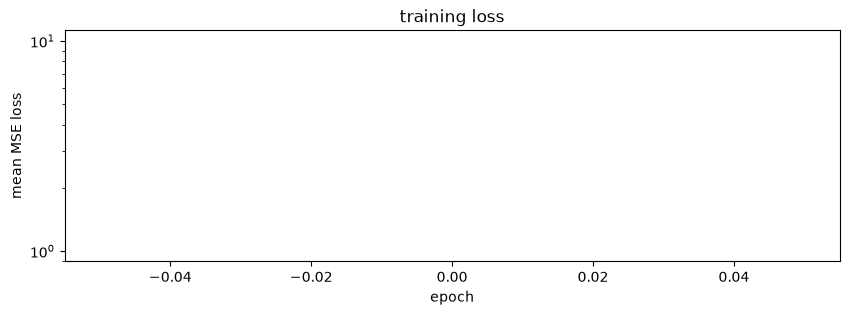

In [53]:
fig, ax = plt.subplots()
ax.plot(epoch_losses)
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("mean MSE loss")
ax.set_title("training loss")
plt.show()

## Checkpoint-reconstruction gallery

Same test clip, decoded with progressively later checkpoints — quality should visibly improve over training.

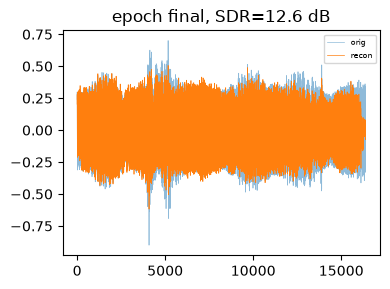

DeepSC_S(
  (semantic_encoder): SemanticEncoder(
    (stem): Sequential(
      (0): Sequential(
        (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (se_blocks): ModuleList(
      (0-3): 4 x SEResNetBlock(
        (transition): Sequential(
          (0): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=4)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (se): SqueezeExcite(
          (pool): AdaptiveAvgPool2d(output_size=1)
          (fc)

In [54]:
test_clip = test_ds[0] if not USE_REAL_DATA else next(iter(torch.utils.data.DataLoader(test_ds, batch_size=1)))[0]
from deepscs.audio import crop_or_pad
test_x = torch.from_numpy(crop_or_pad(test_clip.numpy(), W, np.random.default_rng(0))).view(1, 1, F, L).to(device)

fig, axes = plt.subplots(1, len(checkpoints), figsize=(4 * len(checkpoints), 3))
if len(checkpoints) == 1:
    axes = [axes]
channel.snr_db = 10.0
for ax, (epoch, sd) in zip(axes, checkpoints.items()):
    model.load_state_dict(sd)
    model.eval()
    with torch.no_grad():
        x_hat = model(test_x, channel=channel)
    orig = deframe(test_x[0, 0].cpu().numpy())
    recon = deframe(x_hat[0, 0].cpu().numpy())
    ax.plot(orig, linewidth=0.5, alpha=0.5, label="orig")
    ax.plot(recon, linewidth=0.5, label="recon")
    ax.set_title(f"epoch {epoch}, SDR={sdr(orig, recon):.1f} dB")
    ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

model.load_state_dict(checkpoints[max(checkpoints)])  # restore final weights
model.eval()

## SDR (+ PESQ) vs SNR, across channels

The paper's headline curve: one trained model, evaluated across channel types and SNRs.

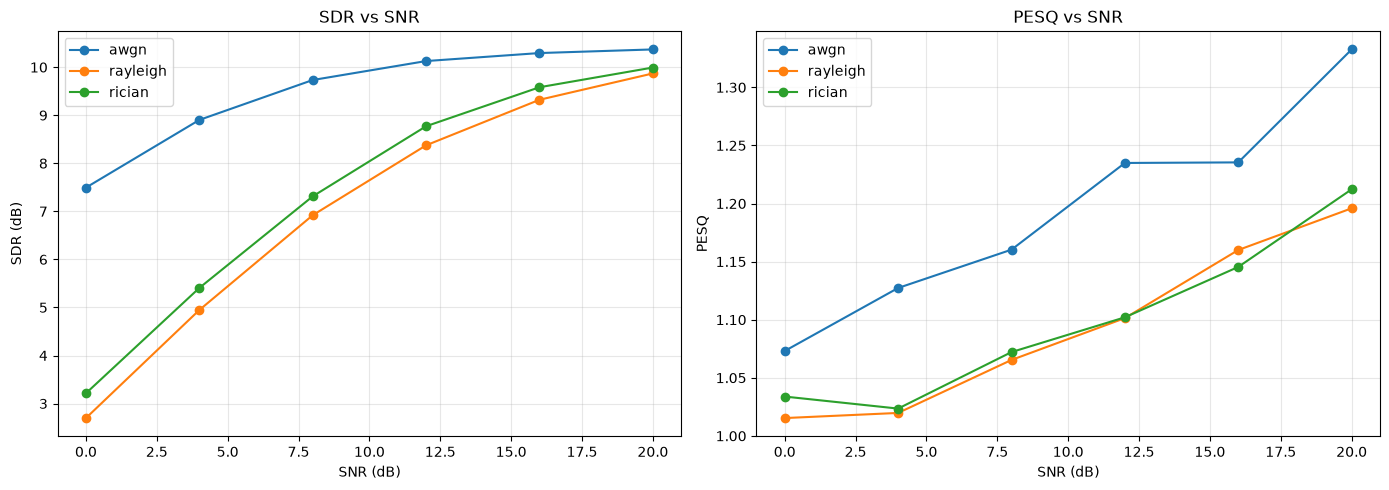

In [56]:
def evaluate(model, channel, snr_range, clips):
    sdrs, pesqs = [], []
    for snr in snr_range:
        channel.snr_db = snr
        clip_sdr, clip_pesq = [], []
        for clip in clips:
            xc = torch.from_numpy(crop_or_pad(clip if isinstance(clip, np.ndarray) else clip.numpy(), W)).view(1, 1, F, L).to(device)
            with torch.no_grad():
                x_hat = model(xc, channel=channel)
            orig = deframe(xc[0, 0].cpu().numpy())
            recon = deframe(x_hat[0, 0].cpu().numpy())
            clip_sdr.append(sdr(orig, recon))
            if HAVE_PESQ:
                try:
                    clip_pesq.append(pesq_fn(SR, orig, recon, "nb"))
                except Exception:
                    pass
        sdrs.append(np.mean(clip_sdr))
        pesqs.append(np.mean(clip_pesq) if clip_pesq else np.nan)
    return sdrs, pesqs

eval_clips = [test_ds[i] for i in range(min(8, len(test_ds)))]
snr_range = list(range(0, 21, 4))

fig, axes = plt.subplots(1, 2 if HAVE_PESQ else 1, figsize=(14 if HAVE_PESQ else 7, 5))
axes = np.atleast_1d(axes)
results = {}
for kind in ["awgn", "rayleigh", "rician"]:
    ch = ChannelLayer(kind, snr_db=10.0)
    sdrs, pesqs = evaluate(model, ch, snr_range, eval_clips)
    results[kind] = (sdrs, pesqs)
    axes[0].plot(snr_range, sdrs, marker="o", label=kind)
    if HAVE_PESQ:
        axes[1].plot(snr_range, pesqs, marker="o", label=kind)

axes[0].set_xlabel("SNR (dB)"); axes[0].set_ylabel("SDR (dB)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("SDR vs SNR")
if HAVE_PESQ:
    axes[1].set_xlabel("SNR (dB)"); axes[1].set_ylabel("PESQ"); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_title("PESQ vs SNR")
else:
    print("pesq not installed — showing SDR only (degrades gracefully per plan)")
plt.tight_layout()
plt.show()

## Cross-channel robustness table

In [57]:
print(f"{'channel':10s} " + " ".join(f"{s:>6} dB" for s in snr_range))
for kind, (sdrs, _) in results.items():
    print(f"{kind:10s} " + " ".join(f"{v:8.2f}" for v in sdrs))

spread = max(np.mean(v[0]) for v in results.values()) - min(np.mean(v[0]) for v in results.values())
print(f"\nmean-SDR spread across channels: {spread:.2f} dB")

channel         0 dB      4 dB      8 dB     12 dB     16 dB     20 dB
awgn           7.49     8.90     9.73    10.13    10.29    10.37
rayleigh       2.70     4.95     6.92     8.37     9.32     9.87
rician         3.21     5.41     7.31     8.77     9.58     9.99

mean-SDR spread across channels: 2.47 dB


## Out-of-distribution probe

**Experiment:** feed a clip the model never trained on (different synthetic seed, or your own recording) and check whether reconstruction quality holds up — a sanity check for whether the learned semantic features generalize past the training distribution.

In [58]:
ood_clip = ToyDataset(n=1, length=W, seed=12345)[0].numpy()
xc = torch.from_numpy(ood_clip).view(1, 1, F, L).to(device)
channel.snr_db = 10.0
with torch.no_grad():
    x_hat = model(xc, channel=channel)
orig = deframe(xc[0, 0].cpu().numpy())
recon = deframe(x_hat[0, 0].cpu().numpy())
print(f"out-of-distribution SDR @ 10 dB: {sdr(orig, recon):.2f} dB")
display(Audio(orig, rate=SR))
display(Audio(recon, rate=SR))

out-of-distribution SDR @ 10 dB: 9.97 dB


## Verify (success criterion #4)

In [59]:
for kind, (sdrs, _) in results.items():
    assert np.all(np.diff(sdrs) > -2.0), f"{kind}: SDR not roughly monotone in SNR"
print("curves monotone in SNR; every result above is paired with a plot + explanation.")
print("Stage 5 verified" + (" on real data." if USE_REAL_DATA else " on toy data — rerun with USE_REAL_DATA after downloading the Edinburgh set for paper-comparable numbers."))

curves monotone in SNR; every result above is paired with a plot + explanation.
Stage 5 verified on toy data — rerun with USE_REAL_DATA after downloading the Edinburgh set for paper-comparable numbers.
